# YOLO Segmentation

객체 탐지가 이미지 안의 객체 위치를 사각형 박스로 찾는 작업이라면, segmentation은 객체가 차지하는 영역을 픽셀 단위에 가깝게 분리하는 작업이다.

- 이미지 분류: 이미지 전체가 무엇인지 예측한다.
- 객체 탐지: 이미지 안의 객체 위치와 클래스를 예측한다.
- 세그멘테이션: 객체가 차지하는 실제 영역을 마스크로 예측한다.

YOLO의 segmentation 모델은 객체의 class, confidence, bounding box뿐 아니라 mask 정보까지 함께 반환한다.

## Object Detection과 Segmentation의 차이

Object Detection은 객체를 사각형 박스로 감싸고 다음과 같은 정보를 출력한다.

- class: 객체의 종류
- confidence: 모델이 해당 객체라고 판단한 확신도
- bounding box: 객체를 둘러싸는 사각형 영역

반면 Segmentation은 객체의 영역을 더 세밀하게 표현한다.

사각형 박스는 객체가 아닌 배경까지 함께 포함할 수 있지만, segmentation mask는 객체가 실제로 차지하는 영역을 더 구체적으로 나타낸다.

따라서 segmentation은 의료 영상, 자율주행, 배경 제거, 제품 결함 검사, 객체 영역 분석처럼 객체의 정확한 형태가 중요한 작업에서 많이 사용된다.

## Semantic Segmentation과 Instance Segmentation

Segmentation은 크게 semantic segmentation과 instance segmentation으로 나누어 볼 수 있다.

Semantic Segmentation은 같은 클래스에 속한 픽셀을 하나의 의미 영역으로 분류한다. 예를 들어 이미지 안의 모든 사람 영역을 `person`으로 표시한다.

Instance Segmentation은 같은 클래스에 속한 객체라도 각각의 객체를 구분한다. 예를 들어 사람 1, 사람 2, 사람 3을 서로 다른 객체 인스턴스로 분리한다.

Ultralytics YOLO의 `-seg` 모델은 일반적으로 instance segmentation 모델로 이해하면 된다. 즉, 객체를 탐지하고 각 객체별 mask를 함께 예측한다.

In [1]:
import os
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Video, display
from ultralytics import YOLO

## 사전학습 YOLO Segmentation 모델 로드

https://docs.ultralytics.com/ko/tasks/segment

Ultralytics YOLO는 detection, segmentation, classification 등 여러 vision task를 지원한다.

Segmentation 모델은 보통 모델 파일명에 `-seg`가 붙는다.

현재 공식 문서는 YOLO26 계열 예제를 기준으로 `yolo26n-seg.pt`를 사용한다. 여기서 `n`은 nano 모델을 의미하며, 크기가 작아 실습용으로 적합하다.

단, 설치된 ultralytics 버전이나 실행 시점에 따라 제공되는 모델명이 다를 수 있다. 만약 `yolo26n-seg.pt` 다운로드가 실패하면 같은 코드 구조에서 `yolo11n-seg.pt` 또는 `yolov8n-seg.pt`로 바꿔 실행하면 된다.

사전학습 YOLO Segmentation 모델도 보통 COCO 데이터셋 기준으로 학습되어 있다. 따라서 사람, 자동차, 버스, 강아지, 고양이 등 COCO에 포함된 일반 객체에 대해 segmentation 결과를 확인할 수 있다.

In [2]:
MODEL_NAME = 'yolo26n-seg.pt'

model = YOLO(MODEL_NAME)

print(model.names)

{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell phone', 68: 'microw

In [3]:
image_source = 'https://ultralytics.com/images/bus.jpg'

results = model.predict(source=image_source, conf=0.25)

print(type(results))
print(len(results))


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 c:\workspaces2\09_deep_learning_multimodal\01_cnn\bus.jpg: 640x480 4 persons, 1 bus, 272.2ms
Speed: 13.2ms preprocess, 272.2ms inference, 12.7ms postprocess per image at shape (1, 3, 640, 480)
<class 'list'>
1


In [5]:
result = results[0]

print('탐지된 박스 수 : ', len(result.boxes))
print('마스크 존재 여부 : ', result.masks is not None)
print(result.boxes)
print(result.masks)

탐지된 박스 수 :  5
마스크 존재 여부 :  True
ultralytics.engine.results.Boxes object with attributes:

cls: tensor([0., 5., 0., 0., 0.])
conf: tensor([0.9191, 0.8942, 0.8869, 0.8661, 0.5763])
data: tensor([[5.1655e+01, 3.9595e+02, 2.4412e+02, 9.0722e+02, 9.1913e-01, 0.0000e+00],
        [1.5271e+01, 2.2787e+02, 8.0743e+02, 7.3954e+02, 8.9421e-01, 5.0000e+00],
        [6.6897e+02, 3.9619e+02, 8.1000e+02, 8.8066e+02, 8.8690e-01, 0.0000e+00],
        [2.2131e+02, 4.0554e+02, 3.4486e+02, 8.5816e+02, 8.6605e-01, 0.0000e+00],
        [3.7722e-01, 5.5002e+02, 7.4516e+01, 8.7369e+02, 5.7630e-01, 0.0000e+00]])
id: None
is_track: False
orig_shape: (1080, 810)
shape: torch.Size([5, 6])
xywh: tensor([[147.8876, 651.5868, 192.4657, 511.2696],
        [411.3519, 483.7035, 792.1622, 511.6706],
        [739.4847, 638.4255, 141.0306, 484.4741],
        [283.0867, 631.8542, 123.5562, 452.6186],
        [ 37.4465, 711.8574,  74.1386, 323.6673]])
xywhn: tensor([[0.1826, 0.6033, 0.2376, 0.4734],
        [0.5078, 0.4479

## segmentation 결과 시각화

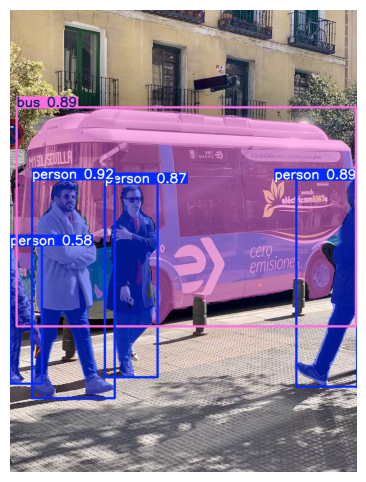

In [6]:
segmented_image = result.plot()

segmented_image_rgb = cv2.cvtColor(segmented_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(segmented_image_rgb)
plt.axis('off')
plt.show()

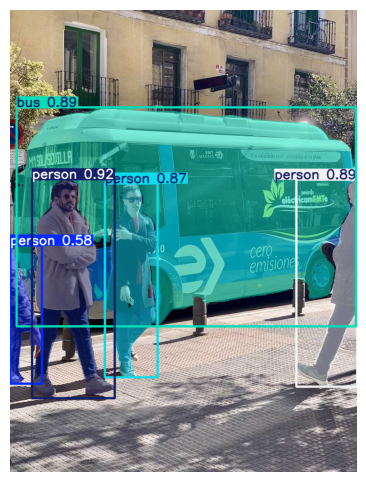

In [8]:
segmented_image = result.plot(color_mode='instance')

segmented_image_rgb = cv2.cvtColor(segmented_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(segmented_image_rgb)
plt.axis('off')
plt.show()

## Mask 데이터 확인

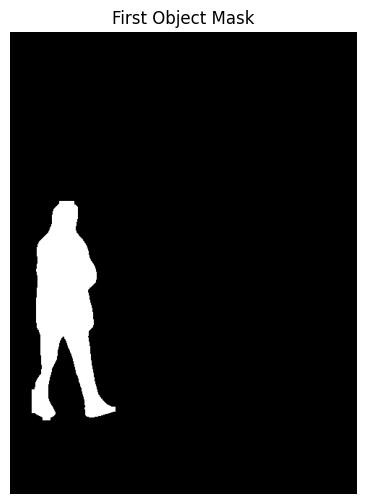

In [15]:
if result.masks is not None:
    masks = result.masks.data.numpy()
    first_mask = masks[0]

    plt.figure(figsize=(6, 6))
    plt.imshow(first_mask, cmap='gray')
    plt.title('First Object Mask')
    plt.axis('off')
    plt.show()

## 동영상 segmentation

In [16]:
video_path = 'https://raw.githubusercontent.com/opencv/opencv/master/samples/data/vtest.avi'

MODEL_NAME = 'yolo26n-seg.pt'
model = YOLO(MODEL_NAME)

results = model(
    video_path,
    save=True,      # 탐지 결과 자동 저장 옵션 
    conf=0.25
)


Found https://raw.githubusercontent.com/opencv/opencv/master/samples/data/vtest.avi locally at vtest.avi
WARNING 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/795) c:\workspaces2\09_deep_learning_multimodal\01_cnn\vtest.avi: 480x640 3 persons, 1 car, 1 truck, 235.6ms
video 1/1 (frame 2/795) c:\workspaces2\09_deep_learning_multimodal\01_cnn\vtest.avi: 480x640 3 persons, 1 car, 1 truck, 187.0ms
video 1/1 (frame 3/795) c:\workspaces2\09_deep_learning_multimodal\01_cnn\vtest.avi: 480x640 3 perso